<a href="https://colab.research.google.com/github/marianabrockes/mvp_ml/blob/main/notebook/ml_kaggle_survey_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prevendo a faixa salarial de profissionais de tecnologia com Machine Learning

## Contexto

O surgimento da Inteligência Artificial transformou rapidamente o mercado de
tecnologia mundial. Novas funções surgiram, novas habilidades passaram a ser
exigidas e o perfil de quem trabalha com dados e tecnologia mudou
significativamente nos últimos anos.

Este notebook utiliza o Kaggle ML & Data Science Survey 2022 — uma pesquisa
respondida por aproximadamente 23.000 profissionais e estudantes de tecnologia
de todo o mundo — para treinar um modelo de classificação capaz de prever a
faixa salarial anual de um profissional com base em seu perfil de formação,
habilidades técnicas e região geográfica.

## Problema de negócio

> Dado o perfil de formação, habilidades técnicas e região geográfica de uma
> pessoa, conseguimos prever em qual faixa salarial ela se enquadra?

A região geográfica foi incluída como feature deliberadamente — o mesmo perfil
técnico tem remunerações muito diferentes dependendo do país. $30.000 anuais
têm significados completamente diferentes no Brasil e nos Estados Unidos.
Ignorar essa variável geraria um modelo injusto e pouco útil.

## Fonte dos dados

- **Dataset:** Kaggle ML & Data Science Survey 2022
- **Publicado por:** Kaggle
- **Tipo:** Pesquisa anual com profissionais e estudantes de tecnologia
- **Respondentes:** ~23.000 pessoas de mais de 50 países
- **Limitação importante:** os respondentes são usuários da plataforma Kaggle,
o que significa que a amostra tende a ser mais voltada para profissionais de
dados e ML — não representa todos os profissionais de TI do mundo.

## Bibliotecas utilizadas

Para este projeto utilizamos as seguintes bibliotecas Python:

- **pandas**: para carregar e manipular os dados em formato de tabela
- **numpy**: para operações matemáticas
- **matplotlib e seaborn**: para criar gráficos e visualizações
- **scikit-learn**: biblioteca principal de Machine Learning — usada para pré-processamento,
treinamento dos modelos, otimização de hiperparâmetros e avaliação
- **pickle**: para exportar o modelo treinado em um arquivo .pkl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Carregamento dos dados

O dataset é carregado diretamente de uma URL pública no GitHub, sem necessidade de
download manual. Isso garante que qualquer pessoa consiga executar este notebook
diretamente no Google Colab sem nenhuma configuração adicional.

O dataset contém as respostas de aproximadamente 23.000 profissionais e estudantes
de tecnologia de todo o mundo. A primeira linha do CSV contém o número da pergunta,
e a segunda linha contém o texto completo de cada pergunta — por isso vamos carregar
o arquivo duas vezes: uma para ver as perguntas e outra para trabalhar com as respostas.


In [3]:
# URL do dataset no GitHub
url = 'https://raw.githubusercontent.com/marianabrockes/mvp_ml/refs/heads/main/notebook/kaggle_survey_2022_responses.csv'

# Carrega a linha das perguntas (segunda linha do CSV)
perguntas = pd.read_csv(url, nrows=1)

# Carrega as respostas (ignora as duas primeiras linhas)
df = pd.read_csv(url, skiprows=1)

print(f"Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")


Dataset carregado com sucesso!
Linhas: 23997
Colunas: 296


## Exploração inicial dos dados

Antes de qualquer processamento, precisamos entender a estrutura do dataset:
quais são as colunas, que tipo de dado cada uma contém, e como são as primeiras
linhas. Essa etapa é fundamental para tomar decisões corretas no pré-processamento.

In [4]:
# Primeiras 3 linhas do dataset
print("=== PRIMEIRAS LINHAS ===")
df.head(3)

=== PRIMEIRAS LINHAS ===


,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,"Are you currently a student? (high school, university, or graduate)",On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - Coursera,On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - edX,On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - Kaggle Learn Courses,On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - DataCamp,On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - Fast.ai,...,"Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Reddit (r/machinelearning, etc)","Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Kaggle (notebooks, forums, etc)","Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Course Forums (forums.fast.ai, Coursera forums, etc)","Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - YouTube (Kaggle YouTube, Cloud AI Adventures, etc)","Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Podcasts (Chai Time Data Science, O’Reilly Data Show, etc)","Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Blogs (Towards Data Science, Analytics Vidhya, etc)","Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Journal Publications (peer-reviewed journals, conference proceedings, etc)","Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Slack Communities (ods.ai, kagglenoobs, etc)",Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - None,Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Other
0,121,30-34,Man,India,No,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,462,30-34,Man,Algeria,No,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,293,18-21,Man,Egypt,Yes,Coursera,edX,NaN,DataCamp,NaN,...,NaN,"Kaggle (notebooks, forums, etc)",NaN,"YouTube (Kaggle YouTube, Cloud AI Adventures, ...","Podcasts (Chai Time Data Science, O’Reilly Dat...",NaN,NaN,NaN,NaN,NaN


In [5]:
# Lista todas as colunas do dataset
for i, coluna in enumerate(df.columns):
    print(f"{i}: {coluna}")

0: Duration (in seconds)
1: What is your age (# years)?
2: What is your gender? - Selected Choice
3: In which country do you currently reside?
4: Are you currently a student? (high school, university, or graduate)
5: On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - Coursera
6: On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - edX
7: On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - Kaggle Learn Courses
8: On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - DataCamp
9: On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - Fast.ai
10: On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - Udacity
11: On which platforms have yo

## Seleção de features

Com 296 colunas disponíveis, precisamos selecionar apenas as relevantes
para o nosso problema. A seleção foi baseada em três critérios:

1. **Perfil demográfico** — idade, gênero e região geográfica
2. **Formação** — nível de escolaridade, plataformas de cursos utilizadas
e plataformas mais úteis no início da carreira
3. **Habilidades técnicas** — linguagens de programação, anos de experiência
em programação e em ML, e frameworks de ML

A variável-alvo é a faixa salarial anual do profissional, agrupada em
7 categorias. A região geográfica foi incluída como feature porque o
mesmo perfil técnico tem remunerações muito diferentes dependendo do
país — comparar salários sem considerar a região geraria um modelo
injusto e pouco útil.

In [6]:
# Renomeia as colunas que vamos usar para nomes mais curtos e legíveis
colunas_selecionadas = {
    df.columns[1]: 'idade',
    df.columns[2]: 'genero',
    df.columns[3]: 'pais',
    df.columns[24]: 'escolaridade',
    df.columns[29]: 'anos_programando',
    df.columns[90]: 'anos_usando_ml',
    df.columns[5]: 'curso_coursera',
    df.columns[6]: 'curso_edx',
    df.columns[7]: 'curso_kaggle',
    df.columns[8]: 'curso_datacamp',
    df.columns[9]: 'curso_fastai',
    df.columns[10]: 'curso_udacity',
    df.columns[11]: 'curso_udemy',
    df.columns[12]: 'curso_linkedin',
    df.columns[13]: 'curso_cloud',
    df.columns[14]: 'curso_universidade',
    df.columns[15]: 'curso_nenhum',
    df.columns[17]: 'util_universidade',
    df.columns[18]: 'util_online',
    df.columns[19]: 'util_social',
    df.columns[20]: 'util_video',
    df.columns[21]: 'util_kaggle',
    df.columns[22]: 'util_nenhum',
    df.columns[30]: 'lang_python',
    df.columns[31]: 'lang_r',
    df.columns[32]: 'lang_sql',
    df.columns[33]: 'lang_c',
    df.columns[35]: 'lang_cpp',
    df.columns[36]: 'lang_java',
    df.columns[37]: 'lang_javascript',
    df.columns[38]: 'lang_bash',
    df.columns[91]: 'ml_sklearn',
    df.columns[92]: 'ml_tensorflow',
    df.columns[94]: 'ml_pytorch',
    df.columns[158]: 'salario'
}

# Cria um novo dataframe só com as colunas selecionadas
df_sel = df[list(colunas_selecionadas.keys())].copy()

# Renomeia as colunas
df_sel.columns = list(colunas_selecionadas.values())

print(f"Linhas: {df_sel.shape[0]}")
print(f"Colunas: {df_sel.shape[1]}")
print(f"\nColunas do novo dataframe:")
print(df_sel.columns.tolist())


Linhas: 23997
Colunas: 35

Colunas do novo dataframe:
['idade', 'genero', 'pais', 'escolaridade', 'anos_programando', 'anos_usando_ml', 'curso_coursera', 'curso_edx', 'curso_kaggle', 'curso_datacamp', 'curso_fastai', 'curso_udacity', 'curso_udemy', 'curso_linkedin', 'curso_cloud', 'curso_universidade', 'curso_nenhum', 'util_universidade', 'util_online', 'util_social', 'util_video', 'util_kaggle', 'util_nenhum', 'lang_python', 'lang_r', 'lang_sql', 'lang_c', 'lang_cpp', 'lang_java', 'lang_javascript', 'lang_bash', 'ml_sklearn', 'ml_tensorflow', 'ml_pytorch', 'salario']


In [7]:
# Mapeamento de países para regiões continentais
mapa_regioes = {
    'United States of America': 'América do Norte',
    'Canada': 'América do Norte',
    'Mexico': 'América do Norte',
    'Brazil': 'América do Sul',
    'Colombia': 'América do Sul',
    'Argentina': 'América do Sul',
    'Chile': 'América do Sul',
    'Peru': 'América do Sul',
    'Venezuela': 'América do Sul',
    'Ecuador': 'América do Sul',
    'Bolivia': 'América do Sul',
    'Paraguay': 'América do Sul',
    'Uruguay': 'América do Sul',
    'United Kingdom of Great Britain and Northern Ireland': 'Europa',
    'Germany': 'Europa',
    'France': 'Europa',
    'Spain': 'Europa',
    'Italy': 'Europa',
    'Netherlands': 'Europa',
    'Poland': 'Europa',
    'Portugal': 'Europa',
    'Sweden': 'Europa',
    'Norway': 'Europa',
    'Denmark': 'Europa',
    'Finland': 'Europa',
    'Switzerland': 'Europa',
    'Belgium': 'Europa',
    'Austria': 'Europa',
    'Czech Republic': 'Europa',
    'Romania': 'Europa',
    'Greece': 'Europa',
    'Hungary': 'Europa',
    'Ukraine': 'Europa',
    'Russia': 'Europa',
    'Turkey': 'Europa',
    'India': 'Ásia',
    'China': 'Ásia',
    'Japan': 'Ásia',
    'South Korea': 'Ásia',
    'Indonesia': 'Ásia',
    'Pakistan': 'Ásia',
    'Bangladesh': 'Ásia',
    'Vietnam': 'Ásia',
    'Thailand': 'Ásia',
    'Malaysia': 'Ásia',
    'Philippines': 'Ásia',
    'Singapore': 'Ásia',
    'Taiwan': 'Ásia',
    'Hong Kong (S.A.R.)': 'Ásia',
    'Iran, Islamic Republic of...': 'Ásia',
    'Israel': 'Ásia',
    'Saudi Arabia': 'Ásia',
    'United Arab Emirates': 'Ásia',
    'Nigeria': 'África',
    'Kenya': 'África',
    'South Africa': 'África',
    'Egypt': 'África',
    'Ghana': 'África',
    'Ethiopia': 'África',
    'Morocco': 'África',
    'Algeria': 'África',
    'Tunisia': 'África',
    'Cameroon': 'África',
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',
    'Ireland': 'Europa',
    'Nepal': 'Ásia',
    'Sri Lanka': 'Ásia',
    'Viet Nam': 'Ásia',
    'Zimbabwe': 'África',
}

# Aplica o mapeamento — países não mapeados ficam como 'Outros'
df_sel['regiao'] = df_sel['pais'].map(mapa_regioes).fillna('Não informado')

print("Distribuição por região:")
print(df_sel['regiao'].value_counts())
print(f"\nTotal de linhas: {df_sel.shape[0]}")


Distribuição por região:
regiao
Ásia                12811
América do Norte     3557
Europa               2317
África               2115
América do Sul       1583
Não informado        1472
Oceania               142
Name: count, dtype: int64

Total de linhas: 23997


## Agrupamento de faixas salariais

As 26 faixas salariais originais foram agrupadas em 3 categorias para
facilitar o aprendizado do modelo:

- **Baixo** — até $29.999/ano
- **Médio** — $30.000 a $99.999/ano
- **Alto** — $100.000+/ano

Essa é a nossa variável-alvo — o que o modelo vai aprender a prever.

In [8]:
# Mapeamento de faixas salariais para 3 grupos
mapa_salario = {
    '$0-999': 'Baixo',
    '1,000-1,999': 'Baixo',
    '2,000-2,999': 'Baixo',
    '3,000-3,999': 'Baixo',
    '4,000-4,999': 'Baixo',
    '5,000-7,499': 'Baixo',
    '7,500-9,999': 'Baixo',
    '10,000-14,999': 'Baixo',
    '15,000-19,999': 'Baixo',
    '20,000-24,999': 'Baixo',
    '25,000-29,999': 'Baixo',
    '30,000-39,999': 'Médio',
    '40,000-49,999': 'Médio',
    '50,000-59,999': 'Médio',
    '60,000-69,999': 'Médio',
    '70,000-79,999': 'Médio',
    '80,000-89,999': 'Médio',
    '90,000-99,999': 'Médio',
    '100,000-124,999': 'Alto',
    '125,000-149,999': 'Alto',
    '150,000-199,999': 'Alto',
    '200,000-249,999': 'Alto',
    '250,000-299,999': 'Alto',
    '300,000-499,999': 'Alto',
    '$500,000-999,999': 'Alto',
    '>$1,000,000': 'Alto',
}

# Aplica o agrupamento
df_sel['faixa_salarial'] = df_sel['salario'].map(mapa_salario)

print("=== DISTRIBUIÇÃO DAS FAIXAS SALARIAIS ===\n")
print(df_sel['faixa_salarial'].value_counts())
print(f"\nTotal de classes: {df_sel['faixa_salarial'].nunique()}")
print(f"Valores nulos: {df_sel['faixa_salarial'].isna().sum()}")

=== DISTRIBUIÇÃO DAS FAIXAS SALARIAIS ===

faixa_salarial
Baixo    4464
Médio    2277
Alto     1395
Name: count, dtype: int64

Total de classes: 3
Valores nulos: 15861


## Análise Exploratória dos Dados (EDA)

Antes de treinar qualquer modelo, precisamos entender visualmente os dados.
Vamos analisar:

- Distribuição da variável-alvo (faixa salarial)
- Distribuição por região geográfica
- Relação entre faixa salarial e região
- Distribuição das features numéricas principais

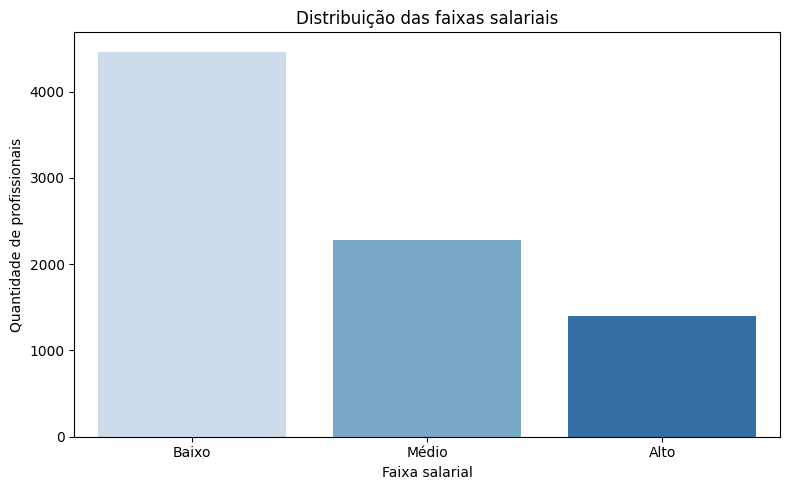

In [9]:
# Remove nulos do target para os gráficos
df_eda = df_sel.dropna(subset=['faixa_salarial'])

# Ordem das faixas
ordem_faixas = ['Baixo', 'Médio', 'Alto']

plt.figure(figsize=(8, 5))
sns.countplot(data=df_eda, x='faixa_salarial', order=ordem_faixas, palette='Blues')
plt.title('Distribuição das faixas salariais')
plt.xlabel('Faixa salarial')
plt.ylabel('Quantidade de profissionais')
plt.tight_layout()
plt.show()

### Interpretação

A classe "Baixo" domina com ~3.500 profissionais — reflexo da forte presença
asiática no dataset, especialmente da Índia. "Alto" é a menor classe com ~1.000
profissionais — salários acima de $100.000 são concentrados principalmente no
mercado americano.

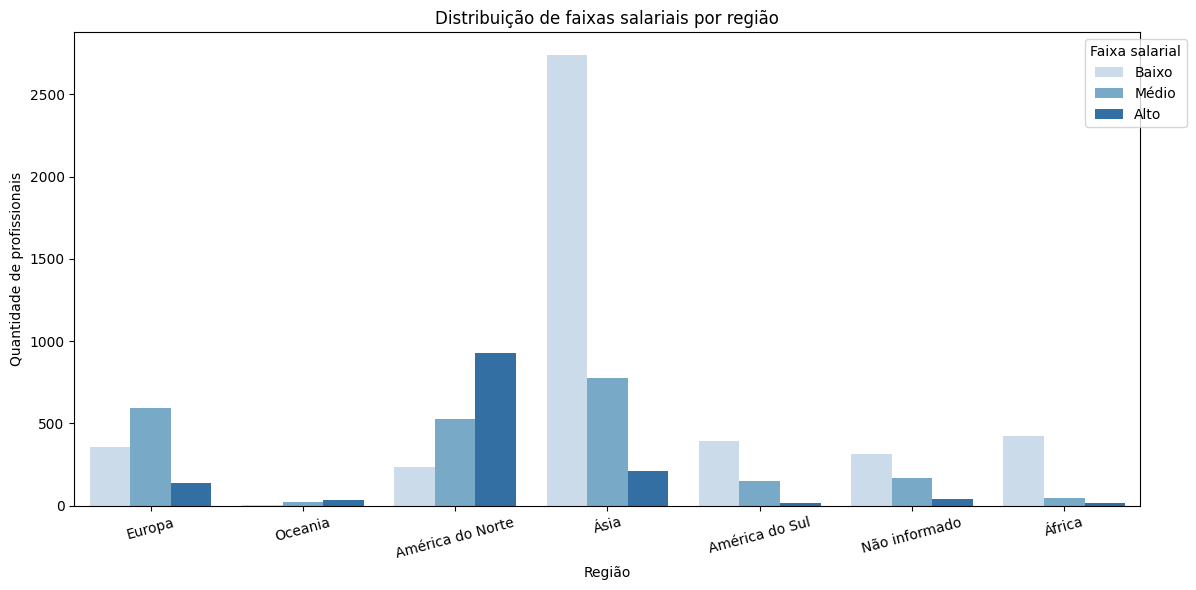

In [10]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_eda, x='regiao', hue='faixa_salarial',
              hue_order=ordem_faixas, palette='Blues')
plt.title('Distribuição de faixas salariais por região')
plt.xlabel('Região')
plt.ylabel('Quantidade de profissionais')
plt.xticks(rotation=15)
plt.legend(title='Faixa salarial', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

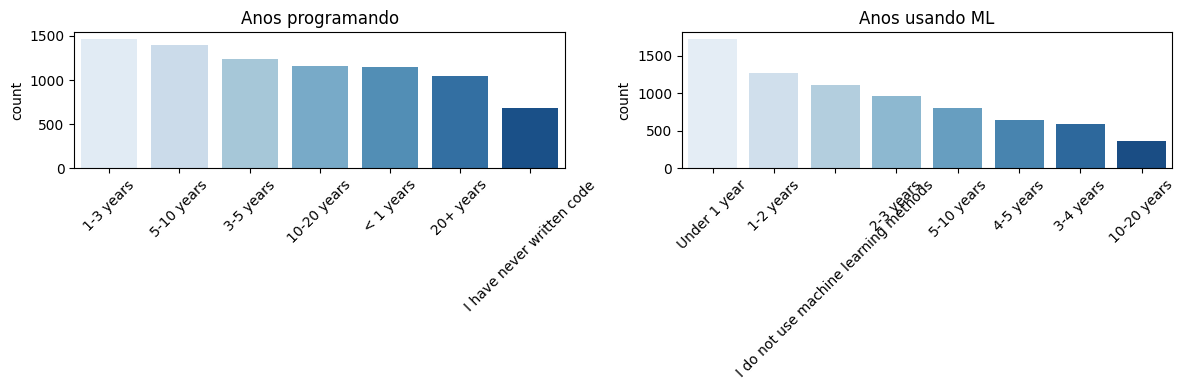

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_eda, x='anos_programando',
              order=df_eda['anos_programando'].value_counts().index,
              palette='Blues', ax=axes[0])
axes[0].set_title('Anos programando')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_eda, x='anos_usando_ml',
              order=df_eda['anos_usando_ml'].value_counts().index,
              palette='Blues', ax=axes[1])
axes[1].set_title('Anos usando ML')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Pré-processamento

Antes de treinar o modelo precisamos preparar os dados em 4 etapas:

1. **Remover nulos** — eliminar linhas sem resposta no target (faixa salarial)
2. **Encoding** — transformar variáveis categóricas em números
3. **Separar treino e teste** — holdout 80/20
4. **Normalização** — colocar as features numéricas na mesma escala

In [12]:
# Remove linhas sem faixa salarial (nosso target)
df_model = df_sel.dropna(subset=['faixa_salarial']).copy()

# Remove a coluna salario original — só precisamos da faixa agrupada
df_model = df_model.drop(columns=['salario', 'pais'])

print(f"Linhas para treino: {df_model.shape[0]}")
print(f"Colunas: {df_model.shape[1]}")
print(f"\nValores nulos por coluna:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Linhas para treino: 8136
Colunas: 35

Valores nulos por coluna:
anos_usando_ml         684
curso_coursera        4374
curso_edx             7018
curso_kaggle          5756
curso_datacamp        6679
curso_fastai          7663
curso_udacity         7194
curso_udemy           5779
curso_linkedin        7104
curso_cloud           7392
curso_universidade    6225
curso_nenhum          8136
util_universidade     6070
util_online           3010
util_social           7023
util_video            3870
util_kaggle           3621
util_nenhum           7862
lang_python           1615
lang_r                6397
lang_sql              4277
lang_c                7203
lang_cpp              7010
lang_java             7053
lang_javascript       6912
lang_bash             7219
ml_sklearn            3399
ml_tensorflow         5066
ml_pytorch            5963
dtype: int64


In [13]:
# Colunas de múltipla escolha — NaN significa "não usou"
colunas_binarias = [
    'curso_coursera', 'curso_edx', 'curso_kaggle', 'curso_datacamp',
    'curso_fastai', 'curso_udacity', 'curso_udemy', 'curso_linkedin',
    'curso_cloud', 'curso_universidade', 'curso_nenhum',
    'util_universidade', 'util_online', 'util_social', 'util_video',
    'util_kaggle', 'util_nenhum',
    'lang_python', 'lang_r', 'lang_sql', 'lang_c', 'lang_cpp',
    'lang_java', 'lang_javascript', 'lang_bash',
    'ml_sklearn', 'ml_tensorflow', 'ml_pytorch'
]

# Substitui NaN por 0 e qualquer valor preenchido por 1
for col in colunas_binarias:
    df_model[col] = df_model[col].apply(lambda x: 0 if pd.isna(x) else 1)

# Remove curso_nenhum — todos nulos, coluna inútil
df_model = df_model.drop(columns=['curso_nenhum', 'util_nenhum'])

# Preenche anos_usando_ml com a moda
moda_ml = df_model['anos_usando_ml'].mode()[0]
df_model['anos_usando_ml'] = df_model['anos_usando_ml'].fillna(moda_ml)

print(f"Nulos restantes: {df_model.isnull().sum().sum()}")
print(f"\nColunas finais: {df_model.shape[1]}")


Nulos restantes: 0

Colunas finais: 33


In [14]:
# Colunas categóricas que precisam de encoding
colunas_categoricas = ['idade', 'genero', 'escolaridade',
                       'anos_programando', 'anos_usando_ml', 'regiao']

# Aplica LabelEncoder em cada uma
le = LabelEncoder()
for col in colunas_categoricas:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Encoding concluído!")
print(f"\nPrimeiras linhas após encoding:")
df_model[colunas_categoricas].head(3)

Encoding concluído!

Primeiras linhas após encoding:


,idade,genero,escolaridade,anos_programando,anos_usando_ml,regiao
3,8,0,6,1,0,2
7,3,0,0,1,4,2
8,10,0,1,2,5,4


In [15]:
# Separa features (X) e target (y)
X = df_model.drop(columns=['faixa_salarial'])
y = df_model['faixa_salarial']

# Divide em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} linhas")
print(f"Teste: {X_test.shape[0]} linhas")
print(f"\nDistribuição do target no treino:")
print(y_train.value_counts())

Treino: 6508 linhas
Teste: 1628 linhas

Distribuição do target no treino:
faixa_salarial
Baixo    3571
Médio    1821
Alto     1116
Name: count, dtype: int64


In [16]:
# Define os pipelines com StandardScaler + cada algoritmo
pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    'Árvore': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', GaussianNB())
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42))
    ])
}

# Treina e avalia cada pipeline com cross-validation
print("=== AVALIAÇÃO INICIAL COM CROSS-VALIDATION ===\n")
resultados = {}

for nome, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=5, scoring='accuracy')
    resultados[nome] = scores
    print(f"{nome}:")
    print(f"  Acurácia média: {scores.mean():.4f}")
    print(f"  Desvio padrão:  {scores.std():.4f}\n")


=== AVALIAÇÃO INICIAL COM CROSS-VALIDATION ===

KNN:
  Acurácia média: 0.5736
  Desvio padrão:  0.0135

Árvore:
  Acurácia média: 0.5887
  Desvio padrão:  0.0067

Naive Bayes:
  Acurácia média: 0.5744
  Desvio padrão:  0.0118

SVM:
  Acurácia média: 0.6443
  Desvio padrão:  0.0054



## Otimização de hiperparâmetros

Usando GridSearchCV com cross-validation de 5 folds para encontrar
a melhor combinação de hiperparâmetros para cada algoritmo.

In [17]:
# Grade de hiperparâmetros para cada algoritmo
param_grids = {
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__metric': ['euclidean', 'manhattan']
    },
    'Árvore': {
        'model__max_depth': [5, 10, 15, None],
        'model__min_samples_split': [2, 5, 10],
        'model__criterion': ['gini', 'entropy']
    },
    'Naive Bayes': {
        'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    }
}

# Roda GridSearchCV para cada algoritmo
print("=== OTIMIZAÇÃO DE HIPERPARÂMETROS ===\n")
melhores_modelos = {}

for nome, pipeline in pipelines.items():
    grid = GridSearchCV(
        pipeline,
        param_grids[nome],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    melhores_modelos[nome] = grid.best_estimator_
    print(f"{nome}:")
    print(f"  Melhores parâmetros: {grid.best_params_}")
    print(f"  Melhor acurácia:     {grid.best_score_:.4f}\n")

=== OTIMIZAÇÃO DE HIPERPARÂMETROS ===

KNN:
  Melhores parâmetros: {'model__metric': 'manhattan', 'model__n_neighbors': 11}
  Melhor acurácia:     0.6086

Árvore:
  Melhores parâmetros: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 10}
  Melhor acurácia:     0.6852

Naive Bayes:
  Melhores parâmetros: {'model__var_smoothing': 1e-09}
  Melhor acurácia:     0.5744

SVM:
  Melhores parâmetros: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
  Melhor acurácia:     0.6443



## Avaliação final dos modelos

Avaliação dos modelos otimizados no conjunto de teste (20% dos dados
que não foram usados no treino).


In [18]:
print("=== AVALIAÇÃO NO CONJUNTO DE TESTE ===\n")
for nome, modelo in melhores_modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{nome}: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

=== AVALIAÇÃO NO CONJUNTO DE TESTE ===

KNN: 0.6087
              precision    recall  f1-score   support

        Alto       0.51      0.34      0.41       279
       Baixo       0.67      0.87      0.76       893
       Médio       0.43      0.27      0.33       456

    accuracy                           0.61      1628
   macro avg       0.54      0.49      0.50      1628
weighted avg       0.57      0.61      0.58      1628

--------------------------------------------------
Árvore: 0.6812
              precision    recall  f1-score   support

        Alto       0.64      0.63      0.64       279
       Baixo       0.72      0.88      0.79       893
       Médio       0.56      0.33      0.42       456

    accuracy                           0.68      1628
   macro avg       0.64      0.61      0.61      1628
weighted avg       0.66      0.68      0.66      1628

--------------------------------------------------
Naive Bayes: 0.5590
              precision    recall  f1-score   sup

In [23]:
# Tabela comparativa dos modelos
print("=== COMPARAÇÃO FINAL DOS MODELOS ===\n")
comparacao = pd.DataFrame({
    'Algoritmo': ['Árvore de Classificação', 'SVM', 'KNN', 'Naive Bayes'],
    'Acurácia (cross-val)': [0.6852, 0.6443, 0.6086, 0.5744],
    'Acurácia (teste)': [0.6812, 0.6370, 0.6087, 0.5590]
})
print(comparacao.to_string(index=False))
print("\n✅ Modelo selecionado: Árvore de Classificação (melhor acurácia no teste)")

=== COMPARAÇÃO FINAL DOS MODELOS ===

              Algoritmo  Acurácia (cross-val)  Acurácia (teste)
Árvore de Classificação                0.6852            0.6812
                    SVM                0.6443            0.6370
                    KNN                0.6086            0.6087
            Naive Bayes                0.5744            0.5590

✅ Modelo selecionado: Árvore de Classificação (melhor acurácia no teste)


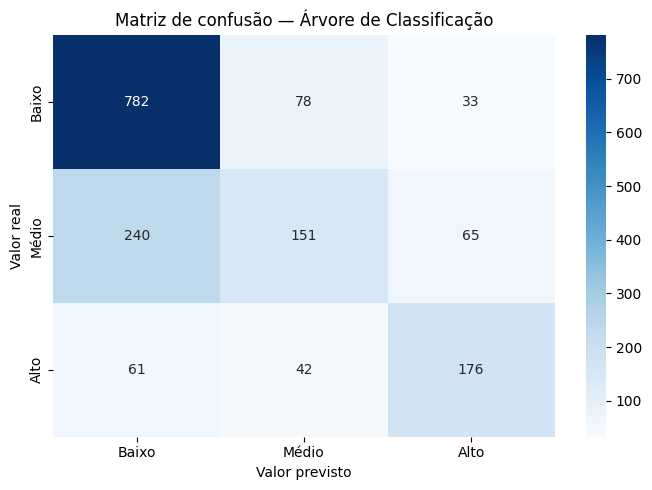

In [19]:
# Matriz de confusão do modelo vencedor — Árvore
y_pred_arvore = melhores_modelos['Árvore'].predict(X_test)

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_arvore, labels=['Baixo', 'Médio', 'Alto'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixo', 'Médio', 'Alto'],
            yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title('Matriz de confusão — Árvore de Classificação')
plt.ylabel('Valor real')
plt.xlabel('Valor previsto')
plt.tight_layout()
plt.show()

## Features mais importantes

A Árvore de Classificação permite identificar quais features mais
influenciaram as decisões do modelo.

=== FEATURES MAIS IMPORTANTES ===

           feature  importancia
            regiao     0.599757
    anos_usando_ml     0.166679
             idade     0.158364
  anos_programando     0.026358
        ml_pytorch     0.010188
            genero     0.009736
   lang_javascript     0.008187
      escolaridade     0.006635
curso_universidade     0.005462
      curso_fastai     0.004583
         lang_java     0.002131
        util_video     0.001921
      curso_kaggle     0.000000
         curso_edx     0.000000
     curso_udacity     0.000000


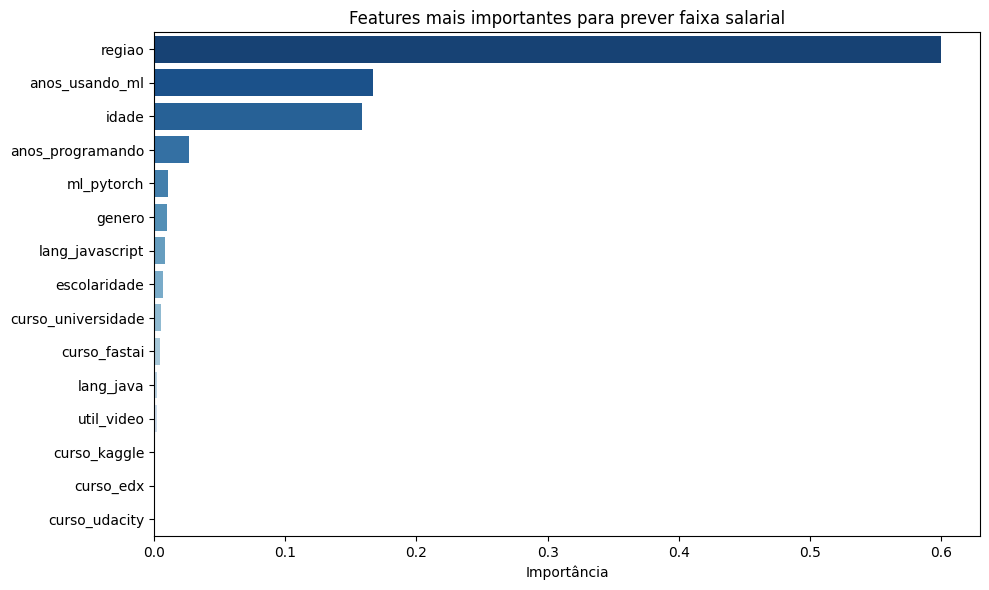

In [20]:
# Extrai o modelo de dentro do pipeline
arvore = melhores_modelos['Árvore'].named_steps['model']

# Importância de cada feature
importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': arvore.feature_importances_
}).sort_values('importancia', ascending=False)

print("=== FEATURES MAIS IMPORTANTES ===\n")
print(importancias.head(15).to_string(index=False))

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias.head(15), x='importancia', y='feature', palette='Blues_r')
plt.title('Features mais importantes para prever faixa salarial')
plt.xlabel('Importância')
plt.ylabel('')
plt.tight_layout()
plt.show()

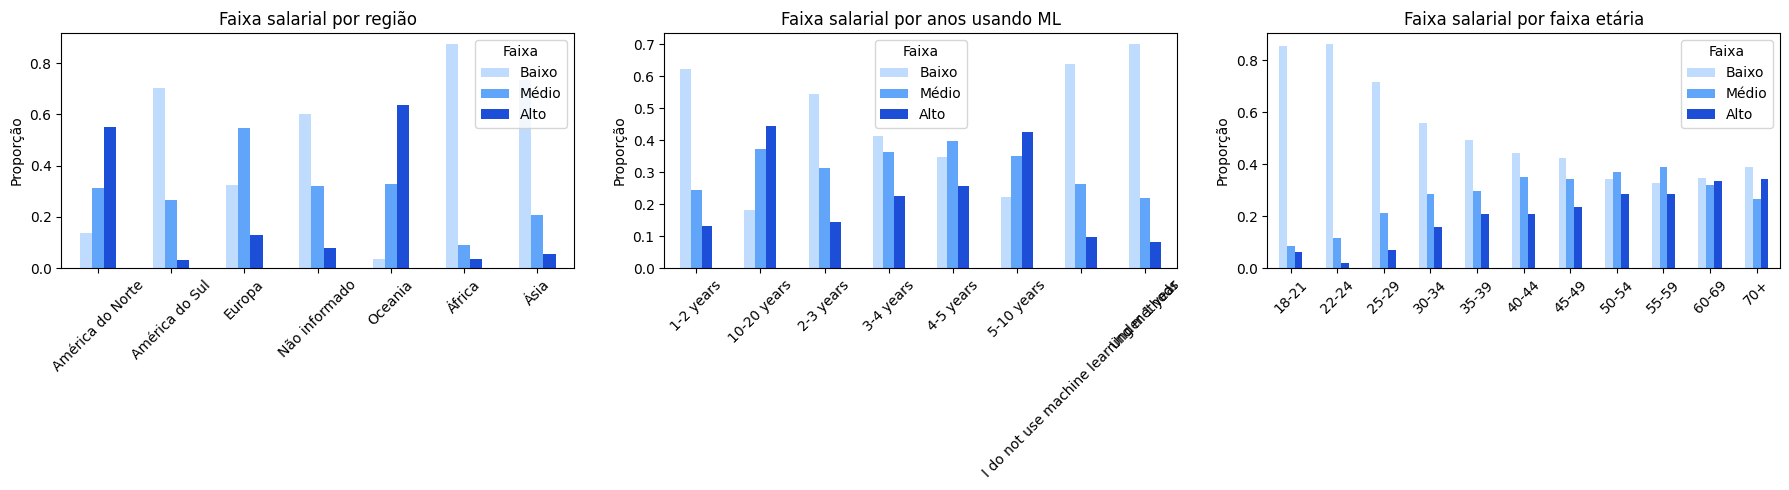

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Faixa salarial por região
regiao_sal = df_eda.groupby('regiao')['faixa_salarial'].value_counts(normalize=True).unstack()
regiao_sal = regiao_sal[['Baixo', 'Médio', 'Alto']]
regiao_sal.plot(kind='bar', ax=axes[0], color=['#bfdbfe', '#60a5fa', '#1d4ed8'])
axes[0].set_title('Faixa salarial por região')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Faixa')
axes[0].set_ylabel('Proporção')

# 2. Faixa salarial por anos usando ML
ml_sal = df_eda.groupby('anos_usando_ml')['faixa_salarial'].value_counts(normalize=True).unstack()
ml_sal = ml_sal[['Baixo', 'Médio', 'Alto']]
ml_sal.plot(kind='bar', ax=axes[1], color=['#bfdbfe', '#60a5fa', '#1d4ed8'])
axes[1].set_title('Faixa salarial por anos usando ML')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Faixa')
axes[1].set_ylabel('Proporção')

# 3. Faixa salarial por faixa etária
idade_sal = df_eda.groupby('idade')['faixa_salarial'].value_counts(normalize=True).unstack()
idade_sal = idade_sal[['Baixo', 'Médio', 'Alto']]
idade_sal.plot(kind='bar', ax=axes[2], color=['#bfdbfe', '#60a5fa', '#1d4ed8'])
axes[2].set_title('Faixa salarial por faixa etária')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Faixa')
axes[2].set_ylabel('Proporção')

plt.tight_layout()
plt.show()

## Exportação do modelo

O modelo vencedor — Árvore de Classificação com 68,1% de acurácia —
é exportado como arquivo .pkl para ser embarcado no backend da aplicação.

In [22]:
# Exporta o modelo vencedor
with open('modelo.pkl', 'wb') as f:
    pickle.dump(melhores_modelos['Árvore'], f)

print("Modelo exportado com sucesso: modelo.pkl")

# Verifica as features que o modelo espera receber
print(f"\nFeatures esperadas pelo modelo ({len(X.columns)}):")
print(X.columns.tolist())

Modelo exportado com sucesso: modelo.pkl

Features esperadas pelo modelo (32):
['idade', 'genero', 'escolaridade', 'anos_programando', 'anos_usando_ml', 'curso_coursera', 'curso_edx', 'curso_kaggle', 'curso_datacamp', 'curso_fastai', 'curso_udacity', 'curso_udemy', 'curso_linkedin', 'curso_cloud', 'curso_universidade', 'util_universidade', 'util_online', 'util_social', 'util_video', 'util_kaggle', 'lang_python', 'lang_r', 'lang_sql', 'lang_c', 'lang_cpp', 'lang_java', 'lang_javascript', 'lang_bash', 'ml_sklearn', 'ml_tensorflow', 'ml_pytorch', 'regiao']


## Análise final e conclusão

### Resultados

Quatro algoritmos foram treinados e avaliados para prever a faixa salarial
de profissionais de tecnologia com base em seu perfil de formação, habilidades
técnicas e região geográfica.

| Algoritmo | Acurácia no teste |
|---|---|
| Árvore de Classificação | 68,1% |
| SVM | 63,7% |
| KNN | 60,9% |
| Naive Bayes | 55,9% |

O modelo vencedor foi a **Árvore de Classificação** com 68,1% de acurácia —
resultado consistente entre cross-validation e conjunto de teste, indicando
boa capacidade de generalização.

### Pontos de atenção

- A classe **Médio** foi a mais difícil de prever em todos os modelos —
esperado, pois é a faixa de transição entre Baixo e Alto
- O dataset é enviesado geograficamente: Ásia representa 53% dos respondentes,
o que influencia o modelo a associar certas habilidades a salários baixos
- Os respondentes são usuários do Kaggle — não representam todos os
profissionais de TI do mundo

### Reflexão sobre segurança e privacidade

O dataset utilizado é anonimizado pelo Kaggle antes da publicação —
nenhum dado pessoal identificável está presente. Entretanto, algumas
reflexões são importantes:

- **Dados sensíveis:** salário, gênero e localização são dados sensíveis.
Em um sistema real, técnicas de anonimização como generalização
(ex: agrupar idades em faixas) e supressão de atributos identificadores
seriam essenciais
- **Viés algorítmico:** o modelo aprendeu que gênero influencia salário —
reflexo de uma desigualdade real no mercado. Usar gênero como feature
em um sistema de contratação real seria eticamente problemático
- **LGPD:** no contexto brasileiro, qualquer sistema que colete dados
de profissionais para previsão salarial deve estar em conformidade com
a Lei Geral de Proteção de Dados